<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

# Import Libraries

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. Finally, os, math and ceil are imported to support file management and mathematical operations.

In [88]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math
from difflib import SequenceMatcher

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler

from sklearn.impute import KNNImputer


# Create Meta Data

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

# Import Dataset

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [89]:
sample = pd.read_csv('../data/sample_submission.csv')
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

## Define new index for our datasets

In [90]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

# Data Preprocessing

## Types Correction

In the EDA phase we noticed some inconsistencies in the variables types. We will further decide what to do with this errors and correct them.

Before even start we create a copy of the original dataframes to avoid any unwanted changes to the original data.

In [91]:
train = train.copy()
test = test.copy()

We are going to decide how to correct the data and this decision will be based on the percentage of incorrect values.

We will analyse the train dataset and take action in both train and test datasets.

In [92]:
# year, previousOwners as float
(train['year'] % 1 != 0).value_counts() # the true values are the incorrect ones
(train['previousOwners'] % 1 != 0).value_counts() # the true values are the incorrect ones

#percentage of incorrect values as float
num_incorrect_year = (train['year'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in year column: {num_incorrect_year:.2f}%')
num_incorrect_previousOwners = (train['previousOwners'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in previousOwners column: {num_incorrect_previousOwners:.2f}%')



Percentage of incorrect values in year column: 2.91%
Percentage of incorrect values in previousOwners column: 3.01%


We decide to round all values of the features even if the percentage of incorrect close to 3%.

In [93]:
def correct_float_columns(df, columns):
    for col in columns:
        df[col] = df[col].round().astype('Int64') #'Int64' is used to keep missing values and still use the round and asType
    return df

train = correct_float_columns(train, ['year', 'previousOwners', 'hasDamage'])
test = correct_float_columns(test, ['year', 'previousOwners', 'hasDamage'])

## Has Damage Column Correction

In the HasDamage column, we have 0's and NaN and we decided to fill the NaN's with 1's to create a boolean variable which will be easier for next analysis. We agree that this change was urgent and because of that was done before the splitting.

In [94]:
train['hasDamage']=train['hasDamage'].fillna(1)
test['hasDamage']=test['hasDamage'].fillna(1)

## Categorical Features correction

### Creating the Correction Function

We start to create a function that correct this strange values by using the library difflib.

In [95]:
from difflib import SequenceMatcher

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def clean_with_diff(
    df, column,
    threshold_short=0.75,
    threshold_long=0.85
    
):
    """
    Groups similar values and replaces them by the most frequent (mode).
    threshold_short: similarity threshold when both strings have <= 5 chars
    threshold_long: similarity threshold otherwise
    min_shared_chars: minimum number of characters in common to merge short strings
    """
    
    values = df[column].dropna().unique()
    groups = []
    used = set()
    # min_shared_chars= [3 if X2[X2['brand'].isin(["bmw", "audi"]) else 2 for brand in X2['brand']]
    
    for v in values:
        if v in used:
            continue
        
        group = [v]
        used.add(v)
        
        for other in values:
            if other in used:
                continue

            # Choose the threshold
            if len(v) <= 5 and len(other) <= 5:
                threshold = threshold_short
                # Check min shared characters
                # shared_chars = len(set(v.lower()) & set(other.lower()))
                # if shared_chars < min_shared_chars:
                    # continue
            else:
                threshold = threshold_long

            # Check similarity
            if similar(v.lower(), other.lower()) >= threshold:
                group.append(other)
                used.add(other)
        
        groups.append(group)
    
    # Create mapping for each group
    mapping = {}
    for group in groups:
        moda = df[df[column].isin(group)][column].mode()[0]
        for item in group:
            mapping[item] = moda
    
    df[column] = df[column].map(mapping).fillna(df[column])
    
    return df


### Correct the values

Now we are able to correct the values:

In [96]:
# Correct 'Brand' column
clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
clean_with_diff(test, 'Brand', threshold_short=0.5, threshold_long=0.6)

# Correct 'transmission' column
clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

# The output show us a part of the dataframe after the values corrections

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I10,2023,Automatic,30700.000000,Petrol,205.0,41.5,1.6,61.0,3,0
106581,VW,Tiguan,2017,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
80886,BMW,2 Series,2016,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2,0
100174,Opel,Grandland X,2019,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1,0
81376,BMW,1 Series,2019,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1,0
81363,BMW,X2,2020,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3,0
76833,Audi,Q5,2019,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4,0


### Check corrections

In [97]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    unique_values_test = test[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print(f"Unique values on the column '{column}' (test): {unique_values_test}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

Unique values on the column 'Brand' (test): ['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

Unique values on the column 'transmission' (test): ['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly.
However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained many unique and incorrect values, some of which were very similar to each other, making it impossible to achieve a perfect correction.

Nevertheless, the vast majority of the data is now properly cleaned and corrected.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [98]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is completly irrelevant so we are going to replace the category as mencioned before.

In [99]:
#Replace 'Other' to 'Unkown'
train['transmission'] = train['transmission'].replace('Other', 'unknown')
test['transmission'] = test['transmission'].replace('Other', 'unknown')
print(train['transmission'].unique())
print(test['transmission'].unique())

['Semi-Auto' 'Manual' 'Automatic' nan 'unknown']
['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan]


## Outliers

Outliers are extreme values that differ significantly from the majority of the data. Their presence can distort statistical analyses and affect the performance of machine learning models. To identify them, we decided to use the Interquartile Range (IQR) method and apply it to all numerical variables. This approach considers values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR as potential outliers. The following analysis identifies the number and percentage of outliers per variable, helping to evaluate whether data cleaning or transformation might be necessary before modeling.

In [100]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']

### Outliers Analysis

In [101]:
def outlier_summary(df, numeric_cols):
    """Generates a summary table of outliers for each numeric column using IQR method."""

    summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Boolean mask for outliers
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)

        total_outliers = outliers.sum()
        pct_outliers = 100 * total_outliers / len(df)

        summary.append({
            "Column": col,
            "Total Outliers": total_outliers,
            "Percentage (%)": round(pct_outliers, 2)
        })

    return pd.DataFrame(summary)

outlier_summary(train, numeric_cols)

,Column,Total Outliers,Percentage (%)
0,year,1791,2.36
1,mileage,3617,4.76
2,tax,20306,26.73
3,mpg,1200,1.58
4,engineSize,716,0.94
5,paintQuality%,0,0.00
6,previousOwners,0,0.00


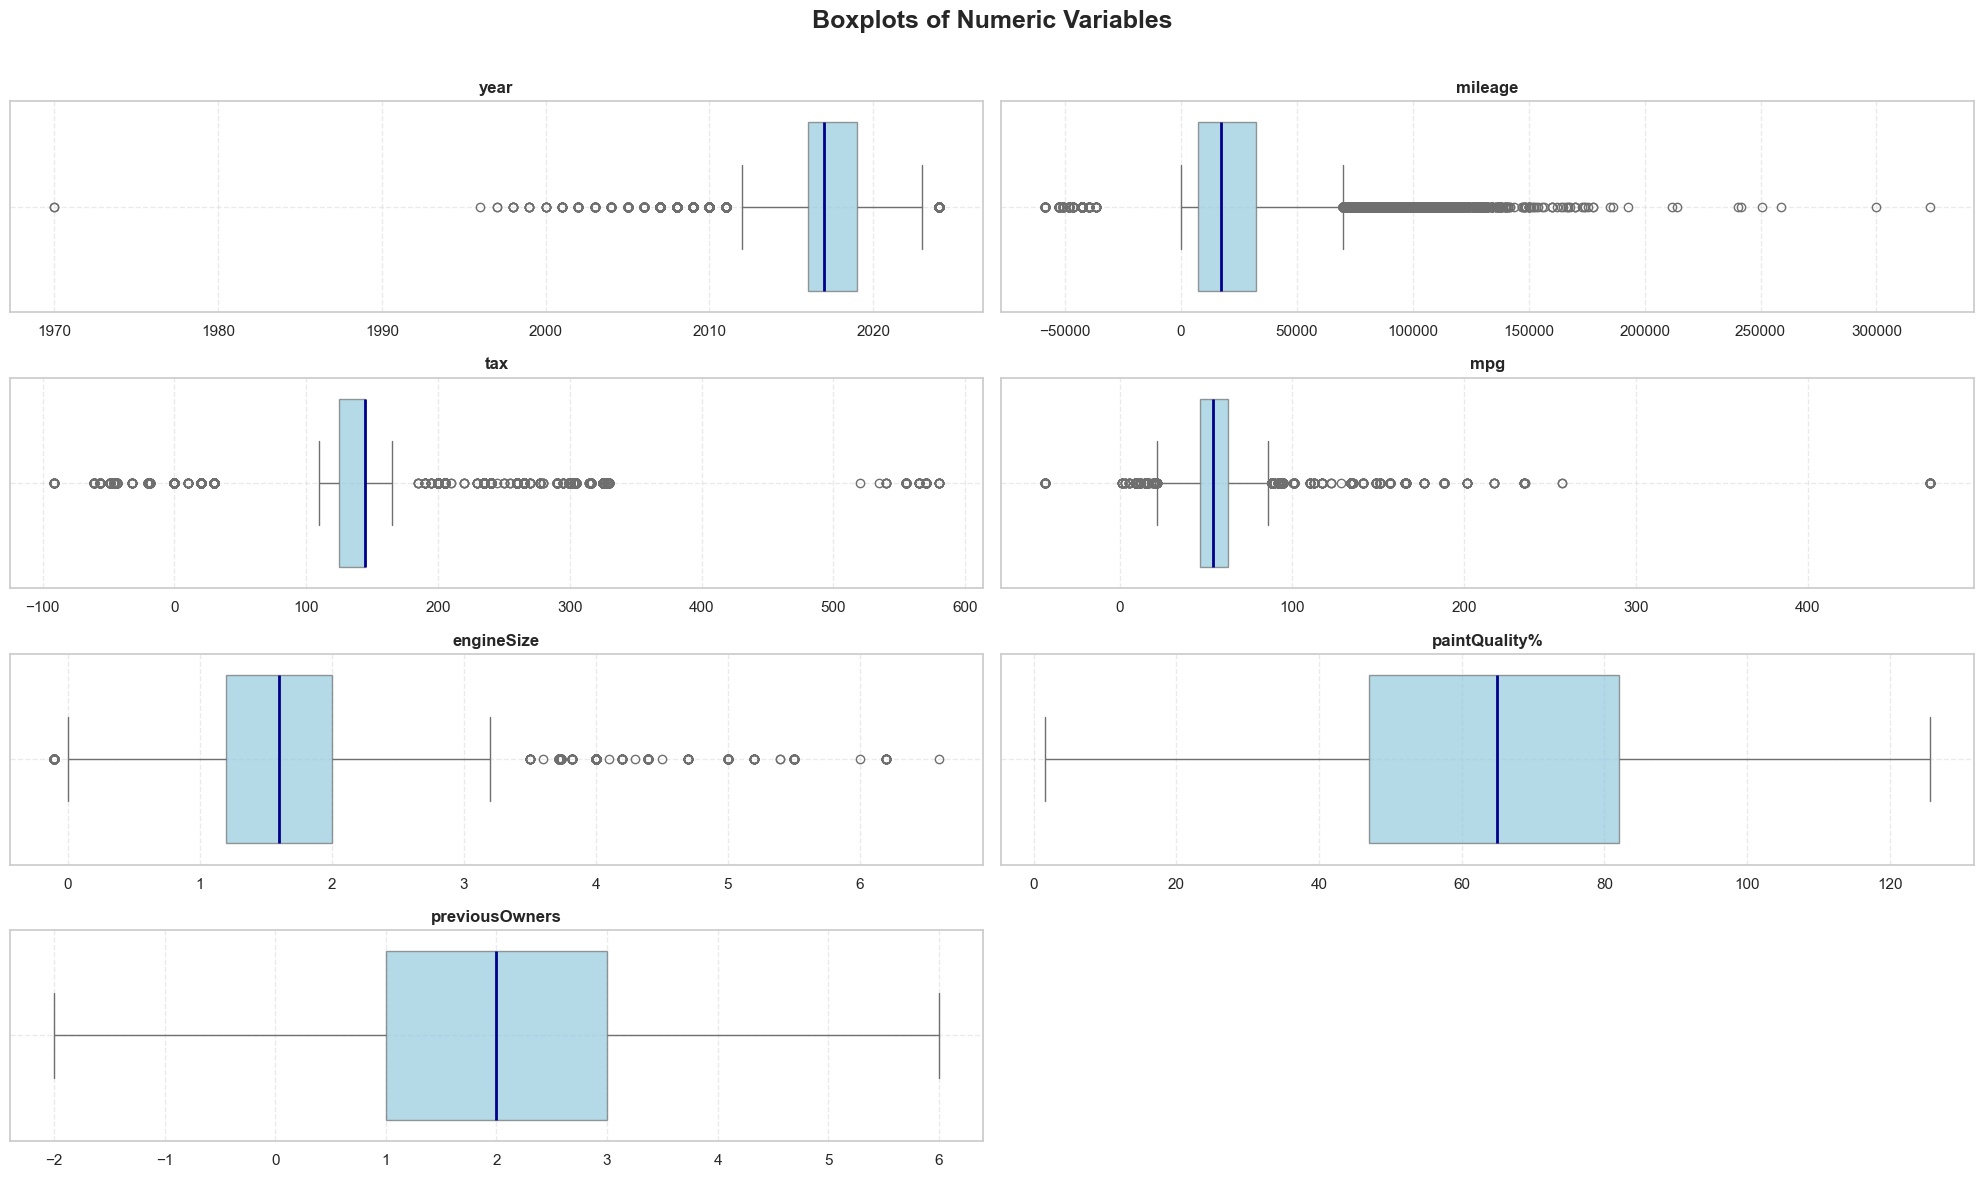

In [102]:
train_num = train[numeric_cols] # DataFrame with only numeric columns to visualize the boxplots

# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(train_num.columns)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(train_num.columns):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=train_num[feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

From the boxplots and the analysis done before we found a lot of outliers and most of them looks like errors. Some features contain negative values (mileage, tax, mpg, engineSize, previousOwners), which are implausible and indicate data-entry errors and the paintQuality% column has values over 100%, which are invalid for a percentage.

### First Outliers Treatment

With the conclusions done before we start our outliers treatment by checking the percentage of negative values to understand if we have a lot of errors.

In [103]:
mileage_negatives = train['mileage']<0
tax_negatives = train['tax']<0
mpg_negatives = train['mpg']<0
engineSize_negatives = train['engineSize']<0
previousOwners_negatives = train['previousOwners']<0


#here we used chatGPT to help us to construct the following DataFrame
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_negatives.value_counts(),
    'tax_negatives': tax_negatives.value_counts(),
    'mpg_negatives': mpg_negatives.value_counts(),
    'engineSize_negatives': engineSize_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_negatives.value_counts()
})

negatives_summary

,mileage_negatives,tax_negatives,mpg_negatives,engineSize_negatives,previousOwners_negatives
False,75604,75595,75937,75889,74052
True,369,378,36,84,371


In [104]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

#Here we used chatGPT to help us constructing the final negatives_table
negatives_percent = {
    'mileage_negatives (%)': mileage_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_negatives.sum() / data_len * 100
}

# Converter para DataFrame (tabela)
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

,mileage_negatives (%),tax_negatives (%),mpg_negatives (%),engineSize_negatives (%),previousOwners_negatives (%)
Percentage of Negatives,0.486,0.498,0.047,0.111,0.488


From the negatives_table we obtain very low percentages for each variable, lower than 1%. So it's possible to conclude that this values are a small part of our data and that if we drop them we don't loose veracity.

We can also see that the total percentage of negative values is lower then 2%.

The first two approaches that came in our minds where drop this negative values or turn them into their absolute value.

We decide to take the 2nd approach.

In [105]:
def correct_negative_values(df, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].abs()
    return df

train = correct_negative_values(train, numeric_cols)
test = correct_negative_values(test, numeric_cols)

Th rest of the data still have some incosistencies in features like PaintQuality% that is a percentage and has values greater than 100%. 

To deal with this we start to check the percentage of this errors.

In [106]:
(train['paintQuality%']>100).value_counts() # the true values are the incorrect ones

percentage = (train['paintQuality%']>100).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in paintQuality% column: {percentage:.2f}%')


Percentage of incorrect values in paintQuality% column: 0.48%


We observed a very small number of values exceeding 100%. These erroneous values account for only 0.4% of the dataset.
Since removing any rows is not allowed, we decided to cap all values at 100%. This approach corrects the impossible values while preserving the rest of the data distribution. Optionally, a flag column could be added to indicate which values were capped, allowing the model to account for these unusual cases if necessary.

In [107]:
# Create a flag column for values that exceed 100%
quality_to_cap = train['paintQuality%'] > 100

# Cap all values at 100%
train['paintQuality%'] = quality_to_cap.clip(upper=100)


To continue the analyse of outliers we will do another boxplot visualization.

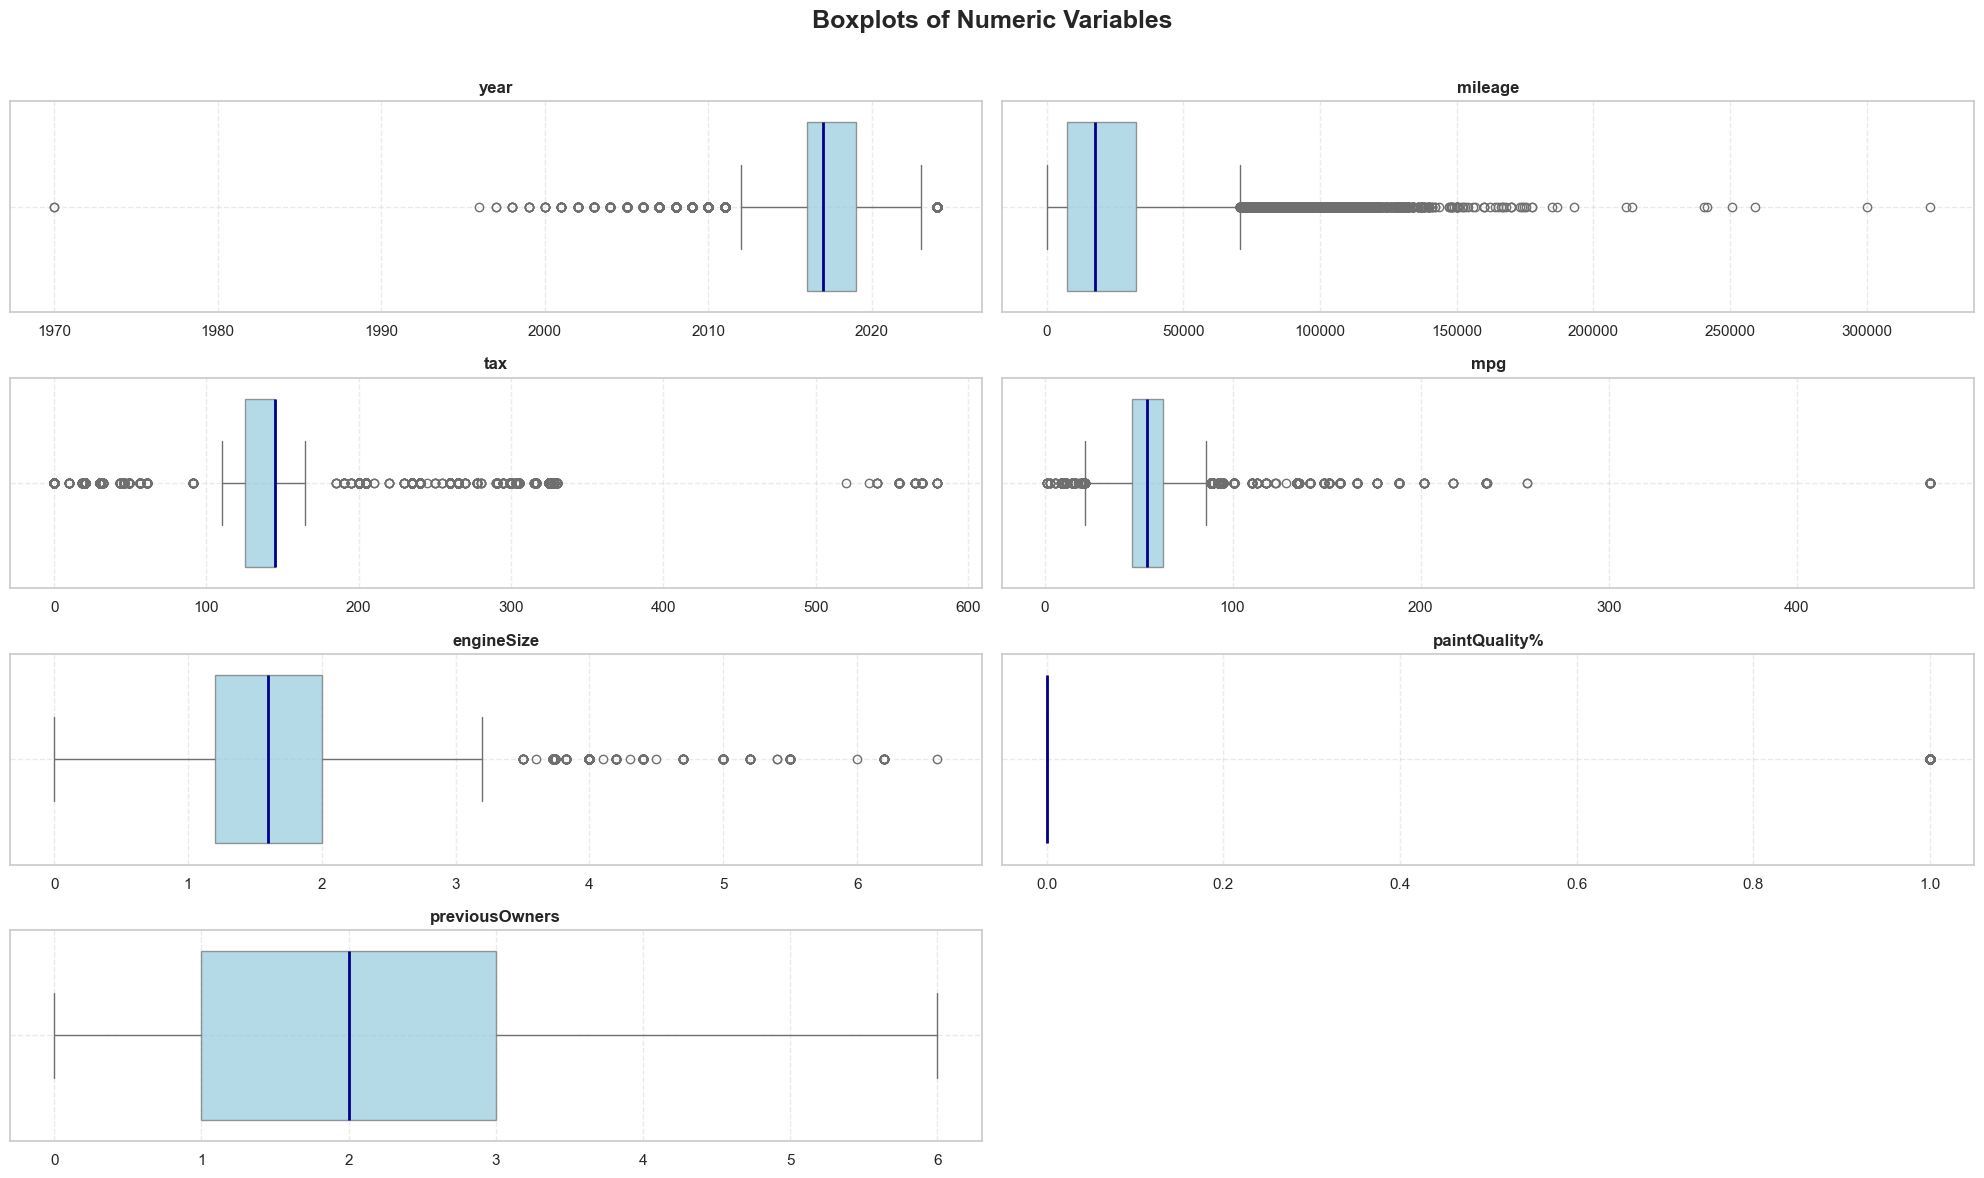

In [108]:
train_num = train[numeric_cols] # DataFrame with only numeric columns to visualize the boxplots


# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(train_num.columns)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(train_num.columns):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=train_num[feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Now X_num has been cleaned of negative values and outliers in paintQuality%. After this we still obser some outliers that need to be treated. For this treatment we will create a function implements the IQR method.

**Important:** Before applying the IQR method to treat outliers we need to split the data into train and validation sets. This is important to avoid data leakage. After splitting the data we can apply the IQR method using only the training set statistics.

## Data Partition

### Define the independent variables as X and the dependent as Y

In [109]:
X = train.drop('price', axis = 1)
y = train['price']

### Split the dataset into train and validation

In [110]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, 
                                                  random_state = 0, 
                                                  shuffle = True)

### Numerical and Categorical columns

In this section we define two lists with the numerical and categorical columns for further use in the preprocessing steps 

In [111]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage']

## Continue Outliers Treatment

In [112]:
def treat_outliers(df, df_to_apply, num_cols, year_col='year'):
    """Cap outliers in numeric columns of df_to_apply based on IQR calculated from df."""
    # Select only numeric columns from the reference
    df_numeric = df[num_cols]
    
    # Calculate Q1, Q3 and IQR
    q1 = df_numeric.quantile(0.25)
    q3 = df_numeric.quantile(0.75)
    iqr = q3 - q1

    # Define lower and upper bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Round bounds only for the year column
    if year_col in num_cols:
        lower_bound[year_col] = int(np.floor(lower_bound[year_col]))
        upper_bound[year_col] = int(np.ceil(upper_bound[year_col]))

    # Cap the outliers in df_to_apply
    df_capped = df_to_apply.copy()
    for col in num_cols:
        df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

    return df_capped

In [113]:
X_train_copy = X_train.copy()  # reference

X_train = treat_outliers(X_train_copy, X_train, num_cols)
X_val = treat_outliers(X_train_copy, X_val, num_cols)
test  = treat_outliers(X_train_copy, test, num_cols)

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

Visualize boxplots one more time

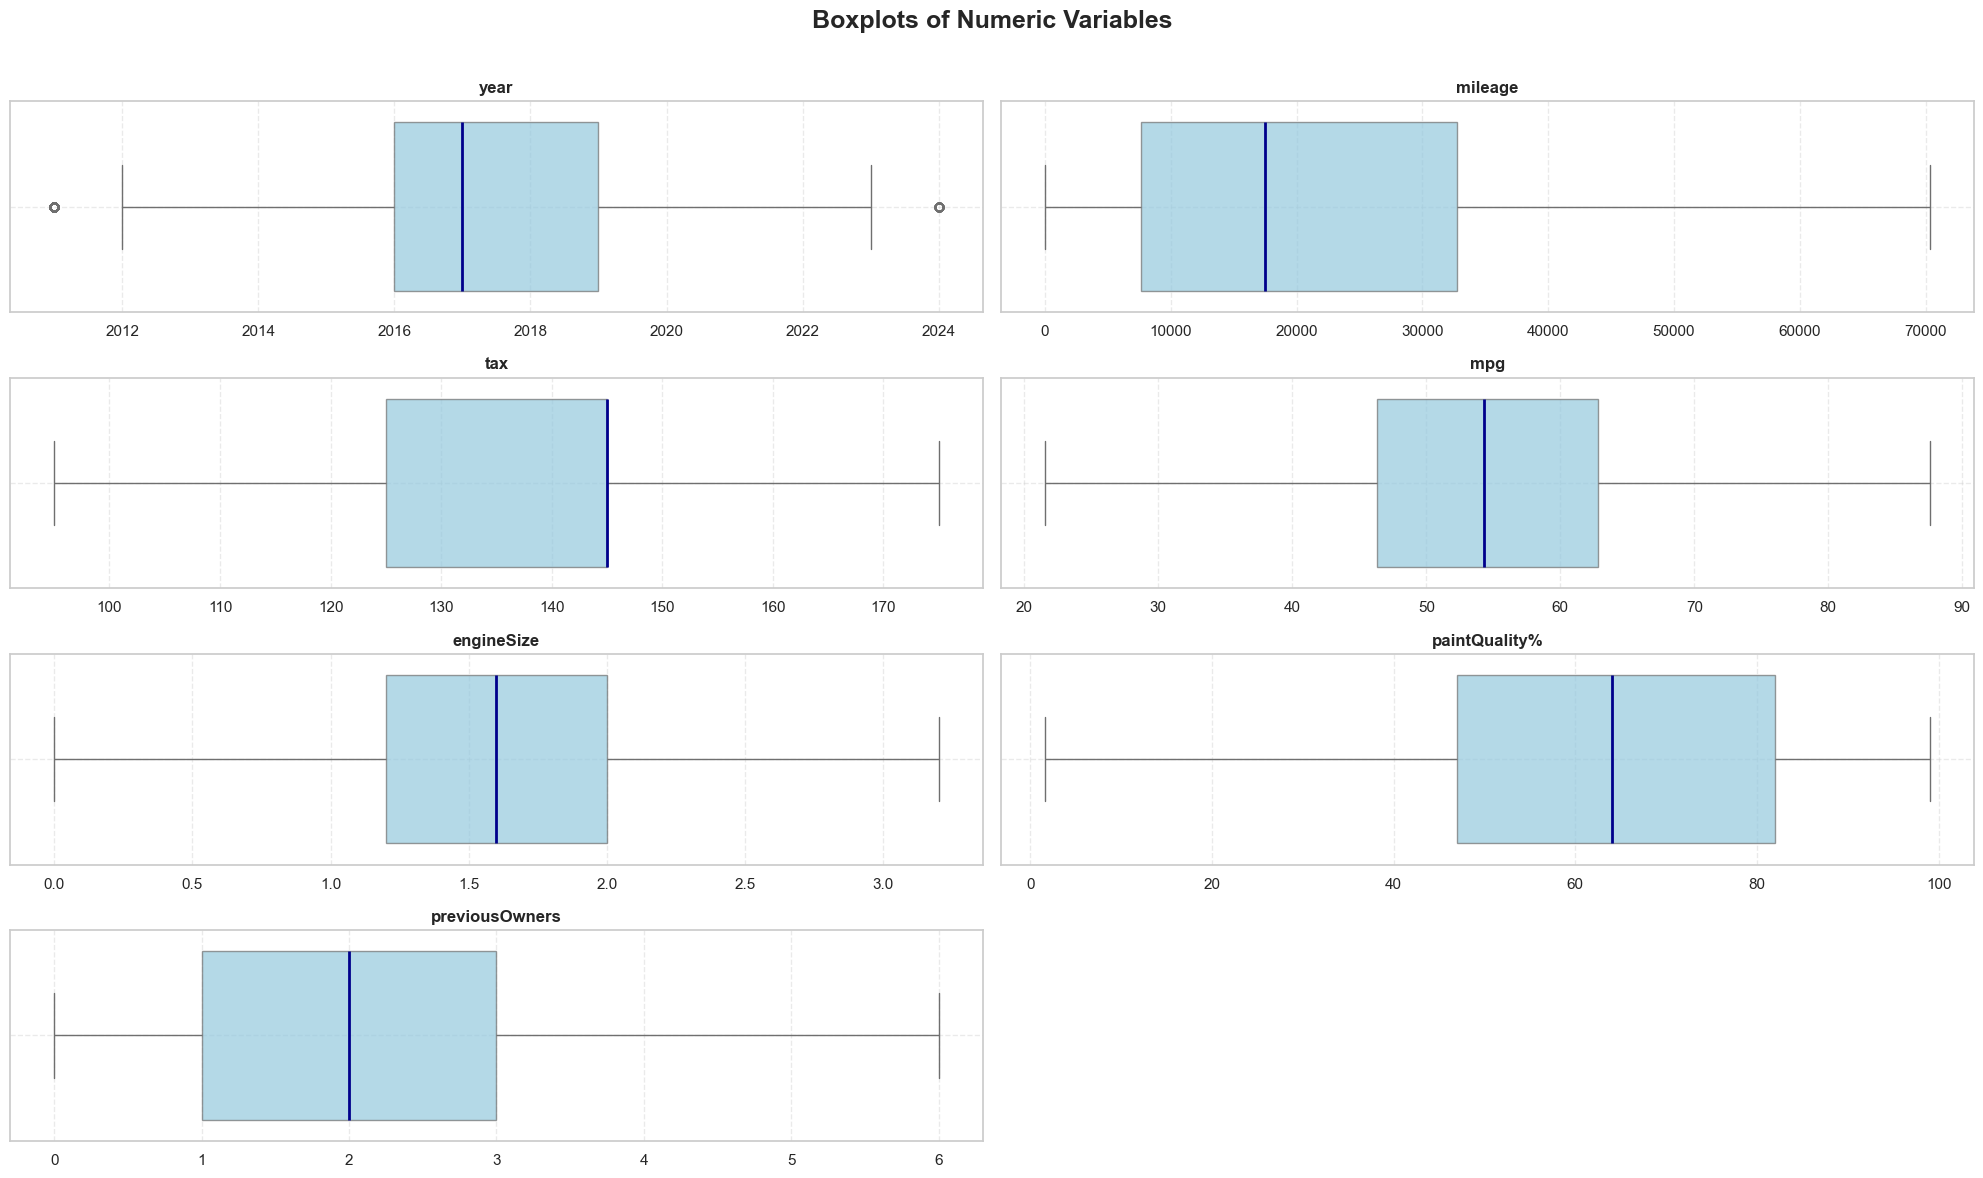

In [ ]:
# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(X_train[num_cols].columns)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(X_train[num_cols].columns):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=X_train[num_cols][feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Feature Engineering Without using median, mean or mode

On this step of the project we create new variables that make sense and can help us predicting our target. For now the variables that we want to add are:
 - `car_age:` calculate the age of the car considering the current year and the year of his registration. This feature help us to capture depreciation, this is, older cars tend to be cheaper.
- `is_recent_model:` binary flag, 1 if the car is less than 3 years old, otherwise 0. We decided to create this feature because highlights newer cars, usually have higher resale prices.

- `mileage_category:` transforms the original continuous mileage feature into an ordered categorical variable with five usage levels according to the total number of mileage they have traveled.  tThis way it's easier to capture differences in vehicle wear and market value.

- `is_hybrid_or_eletric:` binary indicator that is 1 if the fuel type is Hybrid or Electric. Eco-friendly cars often hold higher market value.

- `is_automatic:`binary indicator that is 1 if the type of transmission is automatic or semi-automatic. Automatics typically cost more to buy and maintain.

- `fuel_eficciency_score:` Ratio of mpg / engineSize. Captures how efficiently the car converts fuel given engine capacity.

- `tax_to_engine_ratio:` Tax value divided by engine size. Indicates how expensive it is to maintain the car relative to its power.

- `tax_efficency:` mpg / tax. Measures how fuel-efficient the car is relative to its yearly tax burden.

- `paint_quality_category:` Paint quality binned into Low, Medium, High.

- `has_damage_or_low_paint:` Binary flag, 1 if the car is damaged or has low paint quality (<40%). Combines visible and declared damage into a single condition indicator.

- `is_first_owner:` binary indicator that is 1 if there were no previous owners. First-owner cars tend to have less wear, better care and higher prices. **It was impossible to implement due to missing values**

- `ownership_ratio:` previousOwner / car_age. Captures how frequently ownership changed. Frequent changes might signal reliability issues.

To do this we'll implement some functions that help us defining this new variables.

In [ ]:
def car_age_features(X, current_year=2020, threshold=3):
    """Calculate car age and flag recent cars."""
    X["car_age"] = current_year - X["year"]
    X["is_recent_car"] = (X["car_age"] <= threshold).astype('Int64')
    return X

def mileage_category(X):
    """Create categorical mileage bins."""
    bins = [0, 10_000, 50_000, 100_000, 150_000, float('inf')]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    X['mileage_category'] = pd.cut(X['mileage'], bins=bins, labels=labels, include_lowest=True)
    return X

def fuel_transmission_features(X):
    """Binary flags for eco-friendly cars and automatic transmission."""
    X["is_hybrid_or_electric"] = X["fuelType"].isin(["Hybrid", "Electric"]).astype('Int64')
    X["is_automatic"] = X["transmission"].isin(["Automatic", "Semi-Auto"]).astype('Int64')
    X["fuel_efficiency_score"] = X["mpg"] / X["engineSize"].replace(0, np.nan)
    return X

def tax_and_efficiency_features(X):
    """Calculate economic indicators based on tax and engine size."""
    X["tax_to_engine_ratio"] = X["tax"] / X["engineSize"].replace(0, np.nan)
    X["tax_efficiency"] = X["mpg"] / X["tax"].replace(0, np.nan)
    return X

def condition_features(X):
    """Simplify paint quality and damage info."""
    X["paintQuality_category"] = pd.cut(X["paintQuality%"],
                                        bins=[0, 40, 70, 100],
                                        labels=["Low", "Medium", "High"])
    X["has_damage_or_low_paint"] = ((X["hasDamage"] == 1) | (X["paintQuality%"] < 40)).astype('Int64')
    return X

def ownership_features(X):
    """Ownership-related features."""
    X["is_first_owner"] = (X["previousOwners"] == 0).round().astype('Int64')
    #X["ownership_ratio"] = np.where(X["car_age"] > 0, X["previousOwners"] / X["car_age"], 0)
    #Later, once your missing value handling is complete we can use this code to create a new feature if it's worth it.
    return X

# --- Function to Apply All Feature Engineering Steps ---

def apply_feature_engineering(X):
    """
    Apply all feature engineering transformations in a pipeline using .pipe().
    This ensures code readability and consistent transformations.
    """
    return (X
            .pipe(car_age_features)
            .pipe(mileage_category)
            .pipe(fuel_transmission_features)
            .pipe(tax_and_efficiency_features)
            .pipe(condition_features)
            .pipe(ownership_features)
           )

In [ ]:
X_train_fe = apply_feature_engineering(X_train)
X_val_fe = apply_feature_engineering(X_val)
test_fe = apply_feature_engineering(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

## Feature Engineering considering mean and other calculations

On this step of the project we create new variables that make sense and can help us predicting our target. To create this new features we need to do some calculations like median and average. Because of this we are creating them after the train-validation split.

For now the variables that we want to add are:

- `brand_median_mileage:` mileage median per brand. Typical mileage level for each brand that is able to capture brand usage patterns.

- `brand_avg_engineSize`: engineSize mean per brand. Represents typical engine capacity of each brand.

- `model_median_tax:` median tax per model. Captures model-specific taxation tendencies.

- `fueltype_avg_mpg:` mpg mean peruelType. Average fuel efficiency for each fuel type.

- `brand_avg_age:` car_age mean er brand. Average car age per brand, basically compare newer against older brands.

To do this we'll implement some functions that help us defining this new variables.

In [ ]:
# Create mapping dictionaries based on TRAIN data only ---

# Calculate group statistics using only X_train
brand_median_mileage_map = X_train.groupby('Brand')['mileage'].median().to_dict()
brand_avg_engineSize_map = X_train.groupby('Brand')['engineSize'].mean().to_dict()
model_median_tax_map     = X_train.groupby('model')['tax'].median().to_dict()
fueltype_avg_mpg_map     = X_train.groupby('fuelType')['mpg'].mean().to_dict()
brand_avg_age_map        = X_train.groupby('Brand')['car_age'].mean().to_dict()  # corrected version


# Define a function to apply the mappings to any dataset ---

def apply_group_based_features(df):
    """Apply precomputed group-based features (from training data) to any dataframe."""

    # Map precomputed values from the training set
    df['brand_median_mileage'] = df['Brand'].map(brand_median_mileage_map)
    df['brand_avg_engineSize'] = df['Brand'].map(brand_avg_engineSize_map)
    df['model_median_tax']     = df['model'].map(model_median_tax_map)
    df['fueltype_avg_mpg']     = df['fuelType'].map(fueltype_avg_mpg_map)
    df['brand_avg_age']        = df['Brand'].map(brand_avg_age_map)

    return df


In [ ]:
#Apply mappings to training and validation sets
X_train_fe = apply_group_based_features(X_train)
X_val_fe   = apply_group_based_features(X_val)
test_fe    = apply_group_based_features(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

## Missing Values

### Missing Values Analysis

Before starting to fill this missing values, it is important to analyze the amount of missing values in each feature.
Calculating the percentage of missing values helps identify columns with many absent entries and, consequently, decide whether they are relevant for the model or should be discarded or imputed.

In [ ]:
# Number of rows in the dataset
rows_number = X_train.shape[0]

# Number of missing values per column
missing_counts = X_train.isnull().sum()

# Percentage of missing values per column
missing_percentage = (missing_counts / rows_number) * 100

# Show in DataFrame format, sorted from highest to lowest
missing_df = missing_percentage.sort_values(ascending=False).reset_index()
missing_df.columns = ['Feature', 'Missing_Percent']

print(missing_df)

                    Feature  Missing_Percent
0     fuel_efficiency_score        12.446149
1       tax_to_engine_ratio        12.415917
2            tax_efficiency        12.232635
3                       mpg        10.396040
4                       tax        10.373366
5                     Brand         2.042552
6      brand_avg_engineSize         2.042552
7      brand_median_mileage         2.042552
8             brand_avg_age         2.042552
9                engineSize         2.042552
10           is_first_owner         2.029325
11           previousOwners         2.029325
12            paintQuality%         2.019878
13    paintQuality_category         2.019878
14         model_median_tax         2.012320
15                    model         2.010430
16             transmission         2.006651
17                  car_age         2.002872
18            is_recent_car         2.002872
19                     year         2.002872
20         fueltype_avg_mpg         1.946187
21        

Although some features have missing values, none have a sufficiently high percentage to warrant removal. All columns are considered relevant and can be retained for modeling, with missing values handled through imputation where necessary.

Split features in different groups of missing values percentages.

In [ ]:
low_missing_values = missing_df[missing_df['Missing_Percent'] <= 5.0]['Feature'].tolist()
high_missing_values = missing_df[missing_df['Missing_Percent'] > 5.0]['Feature'].tolist()
print(low_missing_values)
print(high_missing_values)

['Brand', 'brand_avg_engineSize', 'brand_median_mileage', 'brand_avg_age', 'engineSize', 'is_first_owner', 'previousOwners', 'paintQuality%', 'paintQuality_category', 'model_median_tax', 'model', 'transmission', 'car_age', 'is_recent_car', 'year', 'fueltype_avg_mpg', 'fuelType', 'mileage', 'mileage_category', 'has_damage_or_low_paint', 'is_automatic', 'is_hybrid_or_electric', 'hasDamage']
['fuel_efficiency_score', 'tax_to_engine_ratio', 'tax_efficiency', 'mpg', 'tax']


In [ ]:
#Update num_cols variable to include new numeric features
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners',
                'car_age', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'tax_efficiency',
                'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax',
                'fueltype_avg_mpg', 'brand_avg_age']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage', 'is_recent_car', 'mileage_category',
            'is_hybrid_or_electric', 'is_automatic', 'paintQuality_category', 'has_damage_or_low_paint', 'is_first_owner']

Our approach to filling missing values will take into account the percentage of missing data for each feature and will be as follows:
- Features with a low percentage of missing values (<5%) will be imputed using simple methods such as mean, median, or mode.
- Features with a moderate percentage of missing values (5-20%) will be imputed carefully, possibly using more advanced methods such as KNN (if features have low correlation with the others).

### Treat Numeric Missing Values with the median

First we fill the missing values with the median for the features with low percentage:

In [ ]:
for col in num_cols:
      # Check if the column has low or high missing values
    if col in low_missing_values:    
        median_value = X_train[col].median() # calculate median from training set
        X_train.loc[:, col] = X_train[col].fillna(median_value)
        X_val.loc[:, col] = X_val[col].fillna(median_value)
        test.loc[:, col] = test[col].fillna(median_value)

For the rest of the numeric features that have missing values we'll use the KNN imputer technique because there's a higher percentage of missing values. To use this technique we need to normalize the numeric values first using the MinMaxScaler function.

We will do this after enconding and sclaing all features.

### Treat Categorical Missing Values with the mode

In [ ]:
for col in cat_cols:
    mode_value = X_train[col].mode()[0] # Get the most frequent value from training data

    # Fill missing values in both training and validation sets using the training mode
    X_train.loc[:, col] = X_train[col].fillna(mode_value)
    X_val.loc[:, col] = X_val[col].fillna(mode_value)
    test.loc[:, col] = test[col].fillna(mode_value)

In [ ]:
['fuel_efficiency_score', 'tax_to_engine_ratio', 'tax_efficiency', 'mpg', 'tax']

['fuel_efficiency_score',
 'tax_to_engine_ratio',
 'tax_efficiency',
 'mpg',
 'tax']

Now we will check if there are any remaining missing values. Is important to remember that only missing values with low percentage were treated so its normal to still have some features with missing values, but only the features with high percentage of them.

After the analysis that follows this reasoning is confirmed and now we only have 5 features with missing value. The features that we saw to have high percentage of missing values.

In [ ]:
X_train.isna().sum()
# we con

Brand                         0
model                         0
year                          0
transmission                  0
mileage                       0
fuelType                      0
tax                        5490
mpg                        5502
engineSize                    0
paintQuality%                 0
previousOwners                0
hasDamage                     0
car_age                       0
is_recent_car                 0
mileage_category              0
is_hybrid_or_electric         0
is_automatic                  0
fuel_efficiency_score      6587
tax_to_engine_ratio        6571
tax_efficiency             6474
paintQuality_category         0
has_damage_or_low_paint       0
is_first_owner                0
brand_median_mileage          0
brand_avg_engineSize          0
model_median_tax              0
fueltype_avg_mpg              0
brand_avg_age                 0
dtype: int64

## Encoding

Before training machine learning models, it is necessary to convert categorical variables into a numerical format, as most algorithms cannot process non-numeric data directly. This step, known as encoding, ensures that the categorical information can be effectively interpreted by the models without losing its meaning.

In this section, we will apply `One-Hot Encoding` to features with a small number of categories (Brand, Transmission, fuelType) and use a `Label (Ordinal) Encoder` for the variable that contains many distinct categories (model). This approach allows us to represent all categorical variables in a consistent and efficient way, preparing the dataset for further preprocessing and model development.

In [ ]:
def fit_transform_ohe(fit_df, transform_df, cat_cols):
    """Fits a One-Hot Encoder on fit_df and transforms transform_df using the same encoder."""

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore') 
    #sparse=False to get an array as output and handle_unknown='ignore' to avoid errors with unseen categories or missing values

    # Fit on fit_df and transform transform_df
    encoder.fit(fit_df[cat_cols])
    transformed = encoder.transform(transform_df[cat_cols])

    # Create DataFrame with correct column names
    transformed_df = pd.DataFrame(transformed, columns=encoder.get_feature_names_out(cat_cols), index=transform_df.index)

    # Concatenate with other columns and drop originals
    result_df = pd.concat([transform_df.drop(columns=cat_cols), transformed_df], axis=1)

    return result_df

In [ ]:
X_cat_train_copy = X_train[cat_cols].copy() #keep a copy of the original training categorical data for fitting the encoder

X_train = fit_transform_ohe(X_cat_train_copy, X_train, cat_cols)
X_val = fit_transform_ohe(X_cat_train_copy, X_val, cat_cols)
test = fit_transform_ohe(X_cat_train_copy, test, cat_cols)

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Before moving to the next step we need to update the list cat_cols because after enconding new columns were created.

In [ ]:
cat_cols = X_train.drop(num_cols, axis=1).columns.tolist()

## Scaling Features 

Numerical features are scaled to ensure all variables contribute proportionally to the model. In this project, we use MinMaxScaler to transform features to a range between 0 and 1. This preserves relative relationships while preventing features with larger ranges from dominating distance or gradient based algorithms, improving model performance and stability.

In [ ]:


# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train[num_cols])

# Transform and convert back to DataFrame (preserving column names and index)
X_train_scaled = pd.DataFrame(scaler.transform(X_train[num_cols]),
                              columns=num_cols,
                              index=X_train.index)

X_val_scaled = pd.DataFrame(scaler.transform(X_val[num_cols]),
                            columns=num_cols,
                            index=X_val.index)

test_scaled = pd.DataFrame(scaler.transform(test[num_cols]),
                           columns=num_cols,
                           index=test.index)


In [ ]:
X_train_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,car_age,fuel_efficiency_score,tax_to_engine_ratio,tax_efficiency,brand_median_mileage,brand_avg_engineSize,model_median_tax,fueltype_avg_mpg,brand_avg_age
carID,,,,,,,,,,,,,,,,
17123,-3.114830,2.069217,0.433879,-0.423752,-0.847991,-0.793413,1.391786,3.114830,0.123503,0.500524,-0.545612,0.311511,-1.020009,0.188997,-0.742165,0.983971
45563,-0.578492,-0.230152,-1.653192,1.192984,0.842799,0.088227,-0.014294,0.578492,-0.190650,-0.772384,1.780300,-1.434222,1.322307,0.188997,0.726434,-1.112077
64213,-0.578492,0.945947,-1.653192,0.062107,-0.472260,-0.205653,1.391786,0.578492,0.058566,-0.391514,0.917749,1.047611,-0.783531,0.188997,-0.742165,0.802809
40656,-0.071225,-0.186743,0.433879,0.924924,0.842799,0.088227,-1.420373,0.071225,-0.246811,-0.371468,0.128345,-1.434222,1.322307,0.188997,0.726434,-1.112077
48162,0.943310,-0.977464,0.433879,1.192984,-0.096528,-1.136273,1.391786,-0.943310,0.187233,-0.008138,0.262299,-1.799050,-0.730703,0.188997,0.726434,-2.009068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16380,-0.578492,0.631917,NaN,-0.030039,-0.847991,-1.136273,1.391786,0.578492,0.267855,NaN,NaN,0.311511,-1.020009,0.188997,-0.742165,0.983971
68265,1.450578,-0.937320,0.433879,-0.197576,-0.096528,1.067828,0.688746,-1.450578,-0.195147,-0.008138,-0.432588,-0.867825,-0.152294,0.188997,0.726434,-0.849984
63760,-2.100295,2.558647,-1.653192,0.681995,0.091337,1.263748,-0.014294,2.100295,-0.038374,-0.593151,1.390555,1.047611,-0.783531,1.610850,0.726434,0.802809


## KNN Imputer

In [ ]:
# Initialize KNN imputer (you can tune n_neighbors later)
knn_imputer = KNNImputer(n_neighbors=5)

# Fit the imputer only on the training data (to avoid data leakage)
knn_imputer.fit(X_train_scaled)

# Apply the imputer to all splits
X_train_imputed = pd.DataFrame(knn_imputer.transform(X_train_scaled),
                               columns=num_cols,
                               index=X_train_scaled.index)

X_val_imputed = pd.DataFrame(knn_imputer.transform(X_val_scaled),
                             columns=num_cols,
                             index=X_val_scaled.index)

test_imputed = pd.DataFrame(knn_imputer.transform(test_scaled),
                            columns=num_cols,
                            index=test_scaled.index)

In [ ]:
X_train_final = pd.concat([X_train_imputed, X_train[cat_cols]], axis=1)
X_val_final   = pd.concat([X_val_imputed, X_val[cat_cols]], axis=1)
test_final    = pd.concat([test_imputed, test[cat_cols]], axis=1)

Finally we correct all missing values and after we will check the total of missing values for the all dataset to verify if we succed.

In [ ]:
X_train_final.isna().sum().sum()

np.int64(0)

## Save the Processed Data

In [ ]:
# Go one level up from the notebooks folder to reach the repo root
processed_dir = "../data_preprocessed"
os.makedirs(processed_dir, exist_ok=True)

# Save processed datasets as CSV files
X_train_final.to_csv(f"{processed_dir}/X_train_preprocessed.csv", index=False)
X_val_final.to_csv(f"{processed_dir}/X_val_preprocessed.csv", index=False)
test_final.to_csv(f"{processed_dir}/test_preprocessed.csv", index=False)

y_train.to_csv(f"{processed_dir}/y_train.csv", index=False)
y_val.to_csv(f"{processed_dir}/y_val.csv", index=False)